In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv(r"Fraud Detection Dataset.csv")
print(df.head())

  Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
0             T1     4174             1292.76   ATM Withdrawal   
1             T2     4507             1554.58   ATM Withdrawal   
2             T3     1860             2395.02   ATM Withdrawal   
3             T4     2294              100.10     Bill Payment   
4             T5     2130             1490.50      POS Payment   

   Time_of_Transaction Device_Used       Location  \
0                 16.0      Tablet  San Francisco   
1                 13.0      Mobile       New York   
2                  NaN      Mobile            NaN   
3                 15.0     Desktop        Chicago   
4                 19.0      Mobile  San Francisco   

   Previous_Fraudulent_Transactions  Account_Age  \
0                                 0          119   
1                                 4           79   
2                                 3          115   
3                                 4            3   
4                       

In [3]:
df.shape

(51000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [5]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [6]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [7]:
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(df['Transaction_Amount'].median())
df['Time_of_Transaction'] = df['Time_of_Transaction'].fillna(df['Time_of_Transaction'].median())

In [8]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                     0
Transaction_Type                       0
Time_of_Transaction                    0
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [9]:
df['Device_Used'] = df['Device_Used'].fillna(df['Device_Used'].mode()[0])
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])
df['Payment_Method'] = df['Payment_Method'].fillna(df['Payment_Method']).mode()[0]

In [10]:
df.isnull().sum()

Transaction_ID                      0
User_ID                             0
Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

In [11]:
import scipy
from sklearn.preprocessing import MinMaxScaler
numeric_df = df.select_dtypes(include='number')
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(numeric_df)
df[numeric_df.columns] = scaled_values
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,0.793698,0.025758,ATM Withdrawal,0.695652,Tablet,San Francisco,0.00,1.000000,0.923077,UPI,0.0
1,T2,0.876969,0.030995,ATM Withdrawal,0.565217,Mobile,New York,1.00,0.661017,0.153846,UPI,0.0
2,T3,0.215054,0.047807,ATM Withdrawal,0.521739,Mobile,Boston,0.75,0.966102,0.615385,UPI,0.0
3,T4,0.323581,0.001902,Bill Payment,0.652174,Desktop,Chicago,1.00,0.016949,0.230769,UPI,0.0
4,T5,0.282571,0.029714,POS Payment,0.826087,Mobile,San Francisco,0.50,0.474576,0.461538,UPI,0.0


In [12]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
le = LabelEncoder()
df['Transaction_ID'] = le.fit_transform(df['Transaction_ID'])
df['Transaction_Type'] = le.fit_transform(df['Transaction_Type'])
df['Device_Used'] = le.fit_transform(df['Device_Used'])
df['Location'] = le.fit_transform(df['Location'])
df['Payment_Method'] = le.fit_transform(df['Payment_Method'])
df_encoded.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,0.793698,0.025758,ATM Withdrawal,0.695652,Tablet,San Francisco,0.00,1.000000,0.923077,UPI,0.0
1,T2,0.876969,0.030995,ATM Withdrawal,0.565217,Mobile,New York,1.00,0.661017,0.153846,UPI,0.0
2,T3,0.215054,0.047807,ATM Withdrawal,0.521739,Mobile,Boston,0.75,0.966102,0.615385,UPI,0.0
3,T4,0.323581,0.001902,Bill Payment,0.652174,Desktop,Chicago,1.00,0.016949,0.230769,UPI,0.0
4,T5,0.282571,0.029714,POS Payment,0.826087,Mobile,San Francisco,0.50,0.474576,0.461538,UPI,0.0


In [13]:
X = df.drop(columns=['Fraudulent', 'Transaction_ID'])
y = df['Fraudulent']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9522549019607843


In [17]:
X = df.drop(columns=['Fraudulent', 'Transaction_ID'])
y = df['Fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential()

model.add(Dense(128, input_dim=X.shape[1], activation='relu'))
model.add(Dense(64, input_dim=X.shape[1], activation='relu'))
model.add(Dense(32, input_dim=X.shape[1], activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['binary_accuracy'])

history = model.fit(X_train, y_train, epochs=100)
scores = model.evaluate(X_test, y_test)

print("\n%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))
print(model.predict(X).round())

Epoch 1/100


C:\Users\Shambhavee Gune\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1275/1275 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - binary_accuracy: 0.9469 - loss: 0.2188
Epoch 2/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - binary_accuracy: 0.9490 - loss: 0.2043
Epoch 3/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - binary_accuracy: 0.9509 - loss: 0.1974
Epoch 4/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - binary_accuracy: 0.9503 - loss: 0.1990
Epoch 5/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - binary_accuracy: 0.9519 - loss: 0.1933
Epoch 6/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - binary_accuracy: 0.9508 - loss: 0.1972
Epoch 7/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - binary_accuracy: 0.9499 - loss: 0.1988
Epoch 8/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - binary_accuracy: 0.9490 - loss: 0.2016
Epoch 9/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - binary_accuracy: 0.9514 - loss: 0.1944
Epoch 10/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - binary_accuracy: 0.9508 - loss: 0.1966
Epoch 11/100
1275/1275 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms

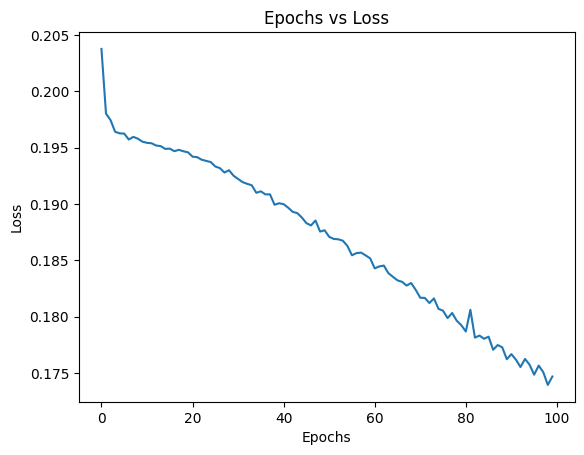

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Epochs vs Loss")
plt.show()

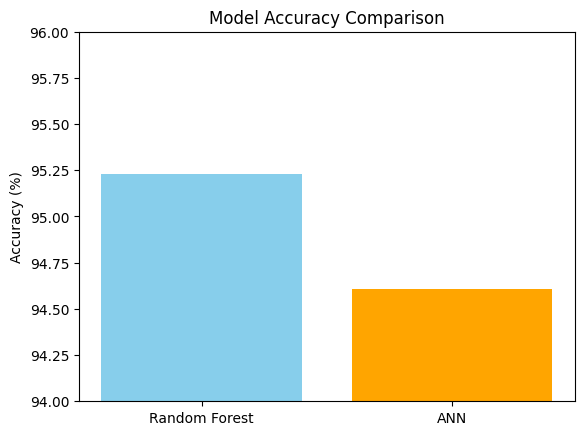

In [19]:
models = ['Random Forest', 'ANN']
accuracies = [95.23, 94.61 ] 

plt.bar(models, accuracies, color=['skyblue', 'orange'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim([94, 96])
plt.show()